# 📊 Week 05 — Data Visualisation Lab
## Guided practical: change, compare, explain


## 0. Setup

In [1]:
# @title
import os
import json
import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from IPython.display import display, clear_output
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4.5)

SEED = 42
rng = np.random.default_rng(SEED)

## 0.1 Data

Run the next cell once. The practical uses synthetic but energy-like data so that
everyone sees the same patterns.

In [2]:
# @title
# Daily data for Estonia, Finland and Latvia
dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")

params = {
    "Estonia": dict(base=23, temp_sens=0.58, price=70, wind=7.5, solar=3.2, co2=315),
    "Finland": dict(base=91, temp_sens=2.15, price=58, wind=25, solar=8.0, co2=105),
    "Latvia":  dict(base=19, temp_sens=0.50, price=68, wind=4.8, solar=2.9, co2=205),
}

rows = []
local_rng = np.random.default_rng(SEED)

for country, p in params.items():
    doy = np.arange(len(dates))
    temp = 6 + 12*np.sin(2*np.pi*(doy-105)/365) + local_rng.normal(0, 3, len(dates))
    heating = np.maximum(15-temp, 0)

    demand = (
        p["base"]
        + p["temp_sens"]*heating
        + 0.8*np.sin(2*np.pi*doy/7)
        + local_rng.normal(0, p["base"]*0.035, len(dates))
    )

    wind = np.maximum(
        0,
        p["wind"]*(1 + 0.28*np.sin(2*np.pi*(doy+30)/365))
        + local_rng.normal(0, p["wind"]*0.20, len(dates))
    )

    daylight = np.maximum(0.08, 0.55 + 0.45*np.sin(2*np.pi*(doy-80)/365))
    solar = np.maximum(
        0,
        p["solar"]*daylight + local_rng.normal(0, p["solar"]*0.10, len(dates))
    )

    renewable_share = np.clip(100*(wind+solar)/np.maximum(demand, 1), 4, 85)

    price = p["price"] + 1.2*heating - 0.9*wind + local_rng.normal(0, 11, len(dates))
    spike_idx = local_rng.choice(len(dates), 7, replace=False)
    price[spike_idx] += local_rng.uniform(90, 200, len(spike_idx))

    co2 = np.clip(
        p["co2"] - 2.1*renewable_share + local_rng.normal(0, 15, len(dates)),
        20, None
    )

    for i, d in enumerate(dates):
        rows.append({
            "date": d,
            "country": country,
            "temperature_c": temp[i],
            "demand_gwh": demand[i],
            "price_eur_mwh": price[i],
            "wind_gwh": wind[i],
            "solar_gwh": solar[i],
            "renewable_share_pct": renewable_share[i],
            "co2_g_kwh": co2[i],
        })

energy_daily = pd.DataFrame(rows)

# Six weeks of hourly demand
idx = pd.date_range("2025-01-06", periods=24*42, freq="h")
h = idx.hour.to_numpy()
dow = idx.dayofweek.to_numpy()
day = np.arange(len(idx))/24

demand_hourly = pd.DataFrame({
    "timestamp": idx,
    "demand_mwh": (
        870
        + 120*np.exp(-((h-8)/2.6)**2)
        + 180*np.exp(-((h-18)/3.2)**2)
        + np.where(dow >= 5, -150, 0)
        + 45*np.sin(2*np.pi*day/35)
        + local_rng.normal(0, 28, len(idx))
    )
}).set_index("timestamp")

# Copy with data-quality problems
bad_demand = demand_hourly.copy()
bad_demand.loc["2025-01-18 18:00", "demand_mwh"] = 1950
bad_demand.loc["2025-01-29 07:00":"2025-01-29 11:00", "demand_mwh"] = np.nan
bad_demand = pd.concat([
    bad_demand,
    bad_demand.loc[["2025-02-03 09:00"]]
]).sort_index()

# Forecast week
fidx = pd.date_range("2025-02-10", periods=24*7, freq="h")
h = fidx.hour.to_numpy()
dow = fidx.dayofweek.to_numpy()

actual = (
    900
    + 120*np.exp(-((h-8)/2.8)**2)
    + 165*np.exp(-((h-18)/3.5)**2)
    + np.where(dow >= 5, -145, 0)
    + local_rng.normal(0, 18, len(fidx))
)

planned = actual.copy()
planned[dow < 5] -= 42
planned[dow >= 5] += 38
planned += local_rng.normal(0, 11, len(fidx))

forecast_week = pd.DataFrame({
    "timestamp": fidx,
    "actual_mwh": actual,
    "planned_mwh": planned,
}).set_index("timestamp")

wind_capacity = pd.DataFrame({
    "year": np.arange(2015, 2024),
    "capacity_mw": [298, 309, 307, 304, 312, 311, 309, 310, 340]
})

energy_daily.head()

,date,country,temperature_c,demand_gwh,price_eur_mwh,wind_gwh,solar_gwh,renewable_share_pct,co2_g_kwh
0,2025-01-01,Estonia,-4.751267,35.648307,96.006303,9.208649,0.739332,27.905902,242.887222
1,2025-01-02,Estonia,-8.832079,36.849482,82.837715,8.655620,0.857238,25.815446,251.977752
2,2025-01-03,Estonia,-3.504011,33.850357,74.333409,9.422281,0.515553,29.358138,253.512694
3,2025-01-04,Estonia,-2.973424,33.934550,89.111401,8.348304,0.674680,26.589375,272.346623
4,2025-01-05,Estonia,-11.684483,38.809623,104.725869,9.077330,0.766762,25.365078,239.272738


# 1. Make a good plot by changing only three things

The plotting code is already written.

## Your task

Change only the marked `TODO`s:

1. add a useful title;
2. add the correct y-axis label and units;
3. change the figure width if you think the dates are too crowded.

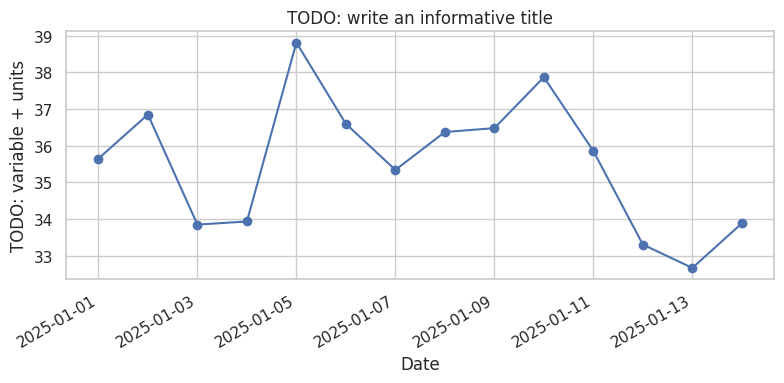

In [3]:
ee14 = energy_daily.query("country == 'Estonia'").head(14)

fig, ax = plt.subplots(figsize=(8, 4))   # TODO: change width if needed
ax.plot(ee14["date"], ee14["demand_gwh"], marker="o")

ax.set_title("TODO: write an informative title")
ax.set_xlabel("Date")
ax.set_ylabel("TODO: variable + units")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 2. Same data, different question


In [4]:
# @title
sector = pd.DataFrame({
    "year": [1995, 2000, 2005, 2010, 2015, 2020],
    "industry": [38.43, 36.55, 35.89, 30.33, 30.05, 29.65],
    "transport": [3.20, 1.81, 1.71, 1.29, 0.69, 0.95],
    "residential": [23.42, 29.23, 26.82, 29.28, 25.22, 27.83],
    "commercial_public": [26.91, 27.94, 31.94, 36.35, 41.05, 39.64],
    "other": [8.03, 4.47, 3.64, 2.75, 2.99, 1.94],
})

## 2A. Improve the bar chart

The code below already creates the 2020 comparison.

Change it so that:

- bars are sorted from smallest to largest;
- the graph becomes horizontal (`barh`) if you prefer;
- the title answers the question more clearly.

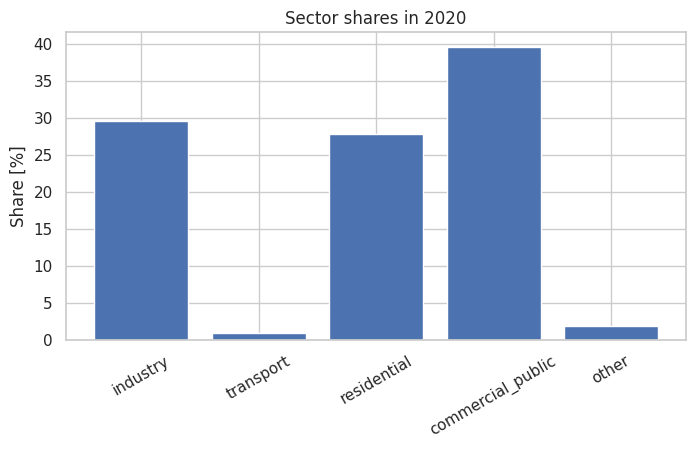

In [5]:
s2020 = (
    sector.query("year == 2020")
    .drop(columns="year")
    .T
    .rename(columns={5: "share_pct"})
)

# TODO 1: sort s2020 by share_pct
# s2020 = ...

fig, ax = plt.subplots(figsize=(8, 4))

# TODO 2: try changing bar() to barh()
ax.bar(s2020.index, s2020["share_pct"])

ax.set_title("Sector shares in 2020")  # TODO 3: improve title
ax.set_ylabel("Share [%]")
plt.xticks(rotation=30)
plt.show()

## 2B. The line plot is already complete

Run it and compare it with the bar chart.

**Question:** which plot is better for:

- comparing sectors in 2020?
- seeing long-term change?

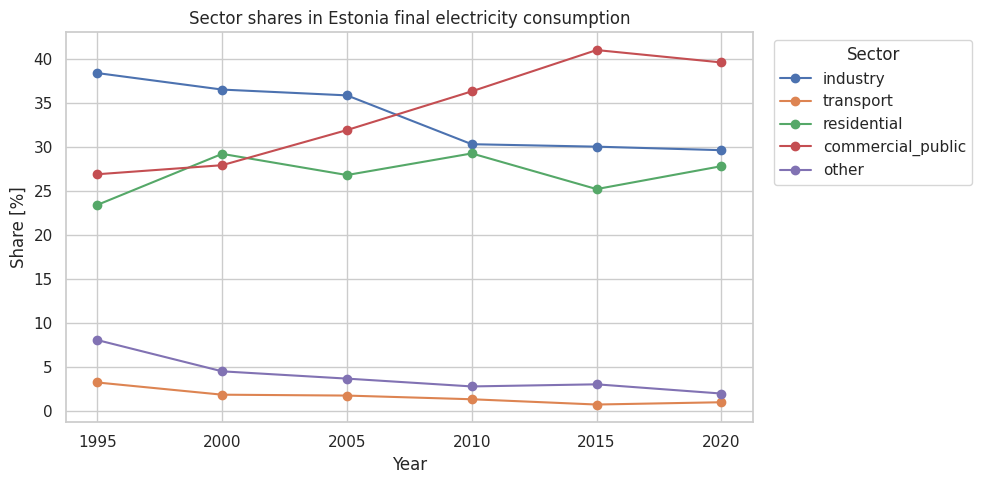

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for col in sector.columns.drop("year"):
    ax.plot(sector["year"], sector[col], marker="o", label=col)

ax.set_title("Sector shares in Estonia final electricity consumption")
ax.set_xlabel("Year")
ax.set_ylabel("Share [%]")
ax.legend(title="Sector", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [7]:
task2_answer = {
    "best_for_2020": "WRITE HERE",
    "best_for_change_over_time": "WRITE HERE",
}
task2_answer

{'best_for_2020': 'WRITE HERE', 'best_for_change_over_time': 'WRITE HERE'}

# 3. Same data, two stories — change only `ylim`

The plot code is already complete.

First run it as given. Then change **only** the y-axis limits.

- Version A: make the increase look dramatic.
- Version B: make the increase look modest.

Do not change the data.

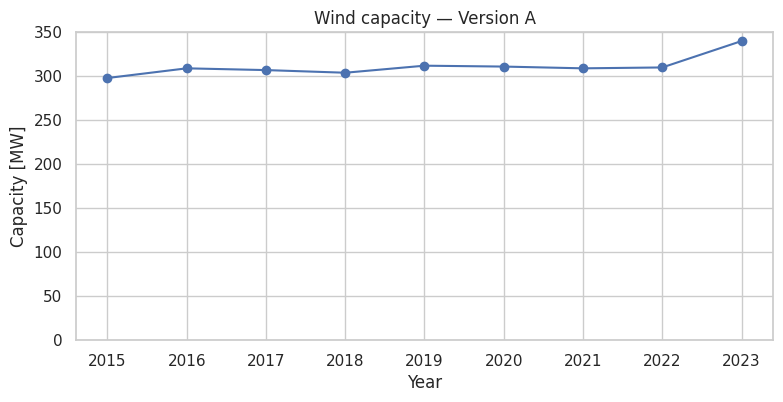

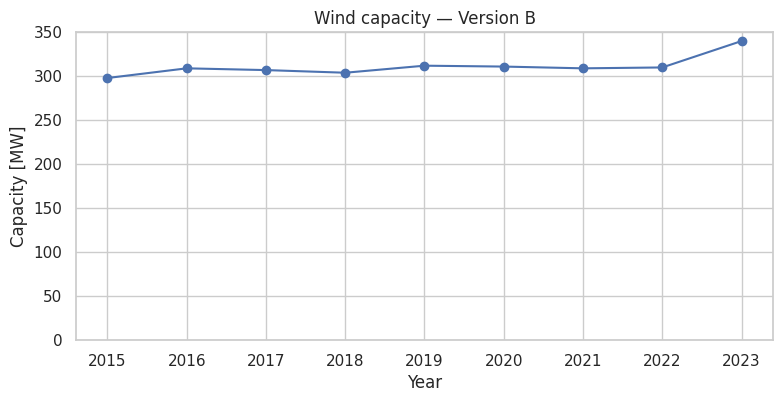

In [8]:
# VERSION A — change only this ylim to make the change look dramatic
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(wind_capacity["year"], wind_capacity["capacity_mw"], marker="o")
ax.set_ylim(0, 350)  # TODO
ax.set_title("Wind capacity — Version A")
ax.set_xlabel("Year")
ax.set_ylabel("Capacity [MW]")
plt.show()

# VERSION B — change only this ylim to make the change look modest
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(wind_capacity["year"], wind_capacity["capacity_mw"], marker="o")
ax.set_ylim(0, 350)  # TODO
ax.set_title("Wind capacity — Version B")
ax.set_xlabel("Year")
ax.set_ylabel("Capacity [MW]")
plt.show()

In [9]:
task3_answer = {
    "did_the_data_change": "WRITE HERE",
    "did_the_visual_impression_change": "WRITE HERE",
    "which_version_is_more_defensible_and_why": "WRITE HERE",
}
task3_answer

{'did_the_data_change': 'WRITE HERE',
 'did_the_visual_impression_change': 'WRITE HERE',
 'which_version_is_more_defensible_and_why': 'WRITE HERE'}

# 4. Aggregation laboratory

This code already resamples the same hourly series.

## Your task

Change only `RESAMPLE_RULE` and compare:

- `"D"` = daily mean
- `"W"` = weekly mean
- optionally `"6h"` = six-hour mean

Observe what disappears as aggregation increases.

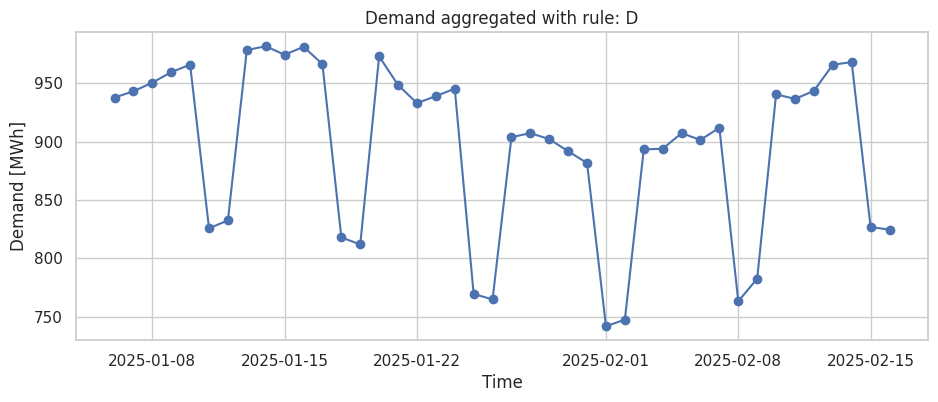

In [10]:
RESAMPLE_RULE = "D"   # TODO: try "6h", "D", and "W"

aggregated = demand_hourly["demand_mwh"].resample(RESAMPLE_RULE).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(aggregated.index, aggregated.values, marker="o")
ax.set_title(f"Demand aggregated with rule: {RESAMPLE_RULE}")
ax.set_xlabel("Time")
ax.set_ylabel("Demand [MWh]")
plt.show()

In [11]:
task4_answer = {
    "6h": "What can you still see?",
    "daily": "What disappeared?",
    "weekly": "What disappeared now?",
}
task4_answer

{'6h': 'What can you still see?',
 'daily': 'What disappeared?',
 'weekly': 'What disappeared now?'}

## 4.1 Interactive comparison

No coding required. Use the dropdown and discuss what each scale makes visible.

In [12]:
def show_scale(scale="Hourly"):
    if scale == "Hourly":
        s = demand_hourly["demand_mwh"]
    elif scale == "Daily":
        s = demand_hourly["demand_mwh"].resample("D").mean()
    else:
        s = demand_hourly["demand_mwh"].resample("W").mean()

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(s.index, s.values)
    ax.set_title(scale + " electricity demand")
    ax.set_xlabel("Time")
    ax.set_ylabel("Demand [MWh]")
    plt.show()

widgets.interact(
    show_scale,
    scale=widgets.Dropdown(options=["Hourly", "Daily", "Weekly"])
);

interactive(children=(Dropdown(description='scale', options=('Hourly', 'Daily', 'Weekly'), value='Hourly'), Ou…

# 5. Time scale — change only the selected interval

The plotting function is ready.

Run it for:

- one week;
- one day.

Only change `START` and `END`.

In [13]:
def plot_period(start, end):
    part = demand_hourly.loc[start:end]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(part.index, part["demand_mwh"])
    ax.set_title(f"Demand from {start} to {end}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Demand [MWh]")
    plt.show()

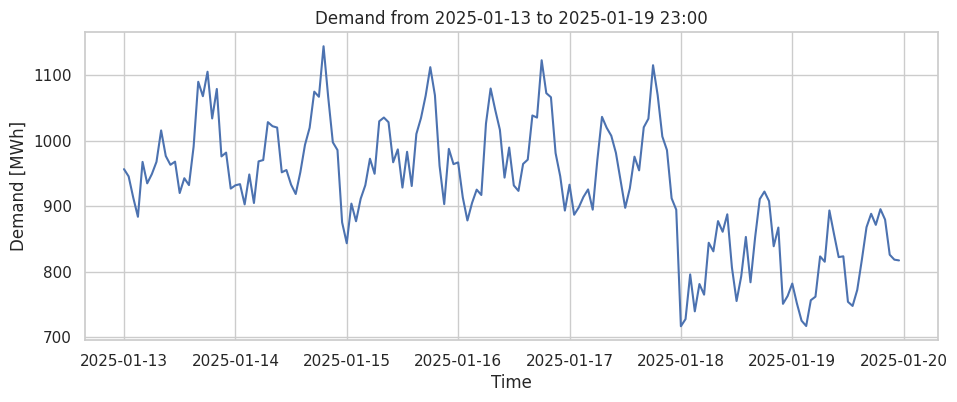

In [14]:
START = "2025-01-13"
END   = "2025-01-19 23:00"

plot_period(START, END)

# TODO: now change START and END to show one single day.

# 6. Small visual experiments

Here the code is complete. Change only one or two parameters and observe the effect.

## 6A. Histogram — change `bins` and `kde`

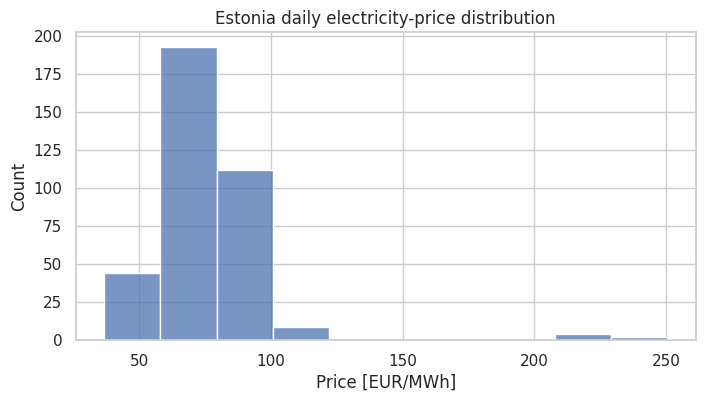

In [15]:
ee = energy_daily.query("country == 'Estonia'")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=ee,
    x="price_eur_mwh",
    bins=10,      # TODO: try 10, 30, 60
    kde=False,    # TODO: try True
    ax=ax
)
ax.set_title("Estonia daily electricity-price distribution")
ax.set_xlabel("Price [EUR/MWh]")
plt.show()

**Question:** can changing the number of bins change what you think the distribution looks like?

## 6B. Scatterplot — add a seasonal category

First run the simple scatterplot. Then uncomment the `hue="season"` line.

In [16]:
ee = ee.copy()
ee["month"] = ee["date"].dt.month
ee["season"] = pd.cut(
    ee["month"],
    bins=[0, 2, 5, 8, 11, 12],
    labels=["Winter", "Spring", "Summer", "Autumn", "Winter2"],
    include_lowest=True
)
ee["season"] = ee["season"].replace({"Winter2": "Winter"})

/tmp/ipykernel_702/276708203.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  ee["season"] = ee["season"].replace({"Winter2": "Winter"})


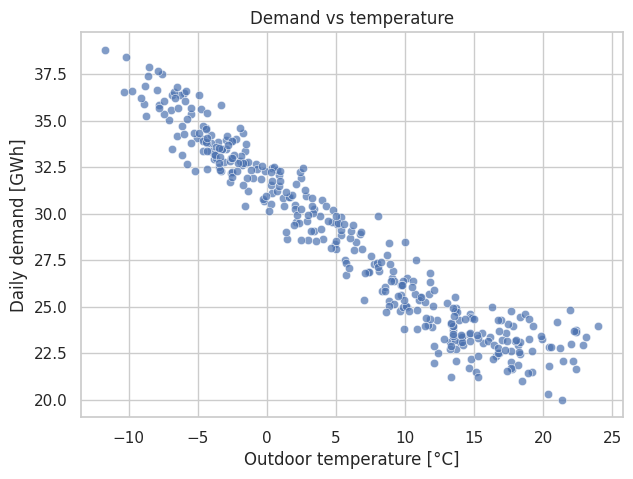

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=ee,
    x="temperature_c",
    y="demand_gwh",
    # hue="season",   # TODO: uncomment this line
    alpha=0.7,
    ax=ax
)
ax.set_title("Demand vs temperature")
ax.set_xlabel("Outdoor temperature [°C]")
ax.set_ylabel("Daily demand [GWh]")
plt.show()

## 6C. Boxplot → violin plot

The code below makes a boxplot.

Change only `sns.boxplot` to `sns.violinplot`.

Which one is easier for you to interpret?

In [18]:
demand_compare = demand_hourly.copy()
demand_compare["day_type"] = np.where(
    demand_compare.index.dayofweek >= 5,
    "Weekend",
    "Weekday"
)
demand_compare = demand_compare.reset_index()

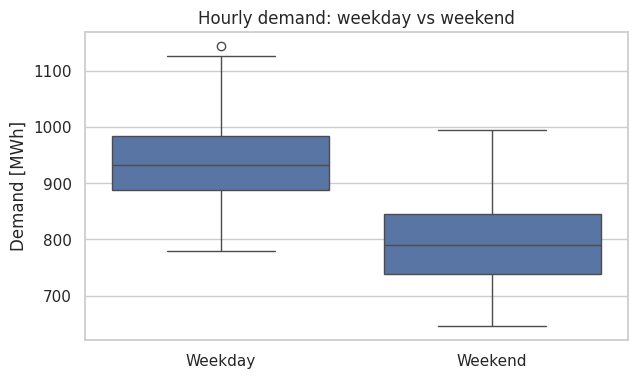

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(   # TODO: replace with sns.violinplot and compare
    data=demand_compare,
    x="day_type",
    y="demand_mwh",
    ax=ax
)

ax.set_title("Hourly demand: weekday vs weekend")
ax.set_xlabel("")
ax.set_ylabel("Demand [MWh]")
plt.show()

# 7. Data-quality detective

The plot is already prepared.

Run it and identify anything suspicious.

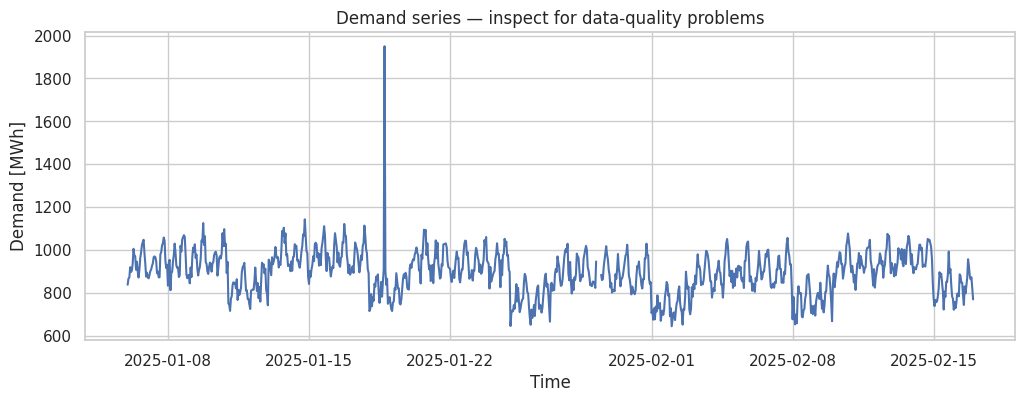

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bad_demand.index, bad_demand["demand_mwh"])
ax.set_title("Demand series — inspect for data-quality problems")
ax.set_xlabel("Time")
ax.set_ylabel("Demand [MWh]")
plt.show()

Now run the checks below. Match each numerical check to something you saw — or did not see — in the plot.

In [21]:
print("Missing values:", bad_demand["demand_mwh"].isna().sum())
print("Duplicate timestamps:", bad_demand.index.duplicated().sum())

print("\nLargest values:")
display(bad_demand.nlargest(5, "demand_mwh"))

Missing values: 5
Duplicate timestamps: 1

Largest values:


,demand_mwh
timestamp,
2025-01-18 18:00:00,1950.000000
2025-01-14 19:00:00,1143.932179
2025-01-09 18:00:00,1126.637730
2025-01-16 18:00:00,1122.569056
2025-01-17 18:00:00,1114.988935


In [22]:
task7_answer = {
    "what_the_plot_found": "WRITE HERE",
    "what_the_index_check_found": "WRITE HERE",
    "why_both_are_needed": "WRITE HERE",
}
task7_answer

{'what_the_plot_found': 'WRITE HERE',
 'what_the_index_check_found': 'WRITE HERE',
 'why_both_are_needed': 'WRITE HERE'}

# 8. Noise vs signal — change only the smoothing window

The code is ready.

Change `WINDOW` between:

- 6
- 24
- 72
- 168

and compare the result.

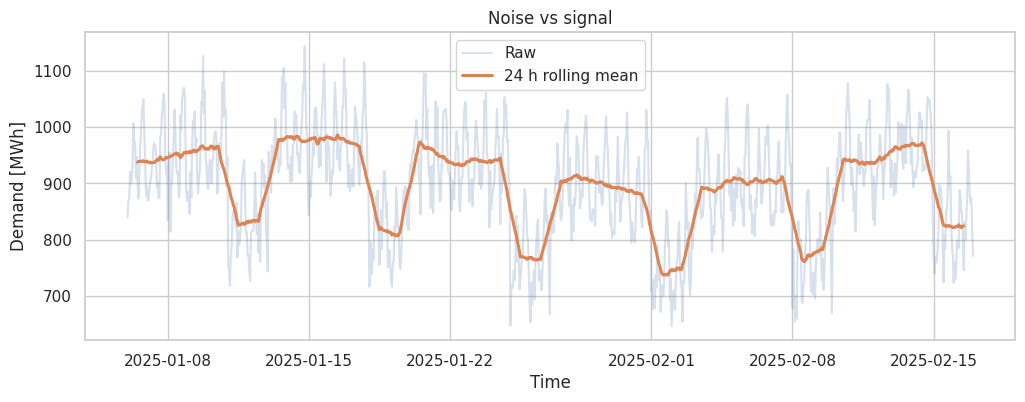

In [23]:
WINDOW = 24   # TODO: try 6, 24, 72, 168

raw = demand_hourly["demand_mwh"]
smooth = raw.rolling(WINDOW, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(raw.index, raw, alpha=0.22, label="Raw")
ax.plot(smooth.index, smooth, linewidth=2.2, label=f"{WINDOW} h rolling mean")
ax.set_title("Noise vs signal")
ax.set_xlabel("Time")
ax.set_ylabel("Demand [MWh]")
ax.legend()
plt.show()

## 8.1 Interactive smoothing

No coding required.

In [24]:
def smoothing_demo(window=24):
    raw = demand_hourly["demand_mwh"]
    smooth = raw.rolling(window, center=True).mean()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(raw.index, raw, alpha=0.2, label="Raw")
    ax.plot(smooth.index, smooth, linewidth=2.2, label=f"{window} h mean")
    ax.set_title("Interactive smoothing")
    ax.set_xlabel("Time")
    ax.set_ylabel("Demand [MWh]")
    ax.legend()
    plt.show()

widgets.interact(
    smoothing_demo,
    window=widgets.IntSlider(min=1, max=168, step=1, value=24)
);

interactive(children=(IntSlider(value=24, description='window', max=168, min=1), Output()), _dom_classes=('wid…

# 9. Metrics vs visualisation

The metric code is complete.

Run it first **without looking at a plot**.

In [25]:
mae = mean_absolute_error(
    forecast_week["actual_mwh"],
    forecast_week["planned_mwh"]
)
rmse = np.sqrt(mean_squared_error(
    forecast_week["actual_mwh"],
    forecast_week["planned_mwh"]
))

print(f"MAE  = {mae:.2f} MWh")
print(f"RMSE = {rmse:.2f} MWh")

MAE  = 40.49 MWh
RMSE = 42.02 MWh


In [26]:
before_plot = "The forecast looks ... because ..."

Now run the prepared visualisation.

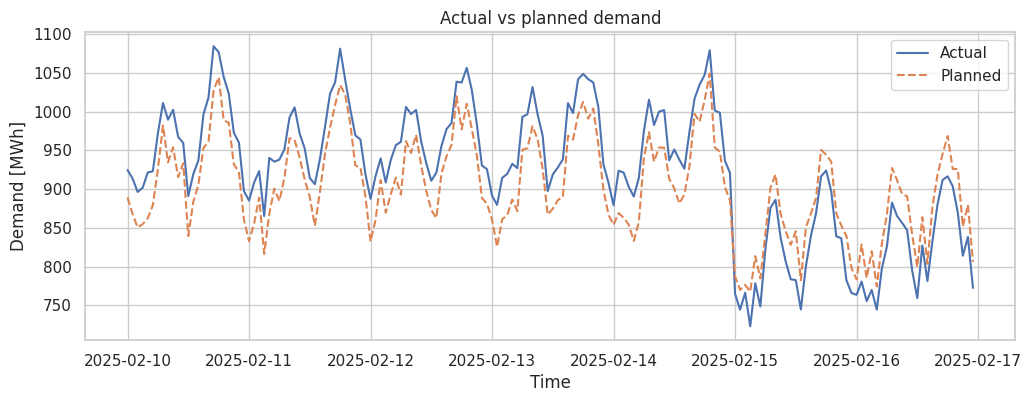

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(forecast_week.index, forecast_week["actual_mwh"], label="Actual")
ax.plot(
    forecast_week.index,
    forecast_week["planned_mwh"],
    linestyle="--",
    label="Planned"
)
ax.set_title("Actual vs planned demand")
ax.set_xlabel("Time")
ax.set_ylabel("Demand [MWh]")
ax.legend()
plt.show()

Finally, run the error plot.

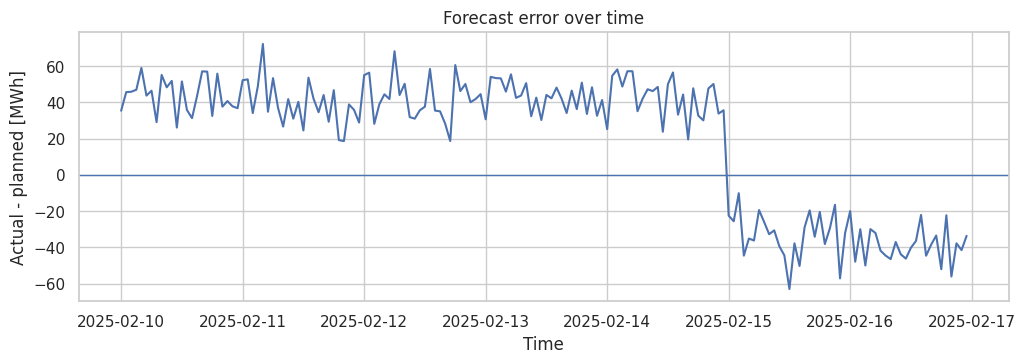

In [28]:
forecast_diag = forecast_week.copy()
forecast_diag["error_mwh"] = (
    forecast_diag["actual_mwh"] - forecast_diag["planned_mwh"]
)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axhline(0, linewidth=1)
ax.plot(forecast_diag.index, forecast_diag["error_mwh"])
ax.set_title("Forecast error over time")
ax.set_xlabel("Time")
ax.set_ylabel("Actual - planned [MWh]")
plt.show()

In [29]:
task9_answer = {
    "what_metrics_show": "WRITE HERE",
    "what_the_plot_adds": "WRITE HERE",
    "systematic_pattern": "WRITE HERE",
}
task9_answer

{'what_metrics_show': 'WRITE HERE',
 'what_the_plot_adds': 'WRITE HERE',
 'systematic_pattern': 'WRITE HERE'}

# 10. Plot Repair Challenge

First run the deliberately bad figure.

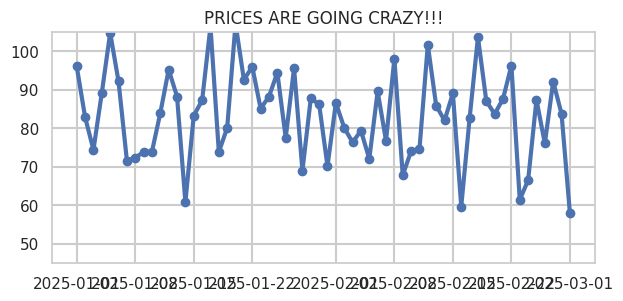

In [30]:
ee60 = energy_daily.query("country == 'Estonia'").head(60)

plt.figure(figsize=(7, 3))
plt.plot(
    ee60["date"],
    ee60["price_eur_mwh"],
    marker="o",
    linewidth=3,
    markersize=6
)
plt.ylim(45, 105)
plt.title("PRICES ARE GOING CRAZY!!!")
plt.grid(True, linewidth=1.5)
plt.show()

The repair template is already written.

Modify only the marked choices:

- title;
- y-axis label;
- `ylim` decision;
- marker usage;
- grid strength.

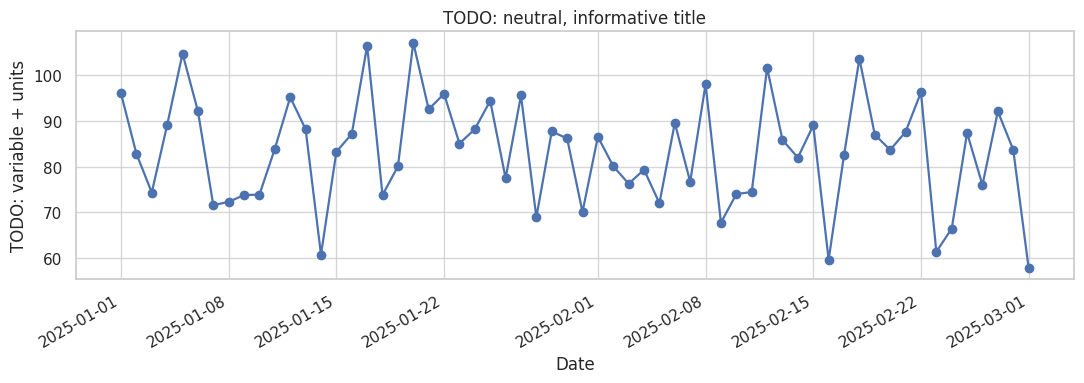

In [31]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    ee60["date"],
    ee60["price_eur_mwh"],
    marker="o",      # TODO: keep or remove?
    linewidth=1.6
)

ax.set_title("TODO: neutral, informative title")
ax.set_xlabel("Date")
ax.set_ylabel("TODO: variable + units")

# TODO: decide whether to keep, remove, or change axis limits
# ax.set_ylim(...)

ax.grid(alpha=0.8)   # TODO: reduce if too strong

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 11. Optional LLM review 🤖

The LLM does not write the plot for you.

Choose one figure from the lab and describe it in `FIGURE_BRIEF`.
The reviewer checks whether your visual choices are defensible.

In [33]:
FIGURE_BRIEF = {
    "question": "WRITE HERE",
    "plot": "WRITE HERE",
    "x": "WRITE HERE",
    "y": "WRITE HERE",
    "time_period": "WRITE HERE",
    "aggregation": "WRITE HERE",
    "axis_choice": "WRITE HERE",
    "claim": "WRITE HERE"
}

In [34]:
review_prompt = f'''
Review this visualisation brief:

Check:
1. plot choice,
2. axis/scale choice,
3. aggregation and time context,
4. whether the claim is stronger than the figure supports,
5. one possible alternative interpretation.

Maximum 5 short comments.
Do not write code.
'''


# 12. Final mini-challenge — choose and modify a template

You do **not** need to start from a blank cell.


### Option A — temperature vs demand
### Option B — renewable share by country
### Option C — electricity-price distribution

Required:

- meaningful title;
- correct units;
- one clear claim;
- one sentence explaining how the figure could become misleading.

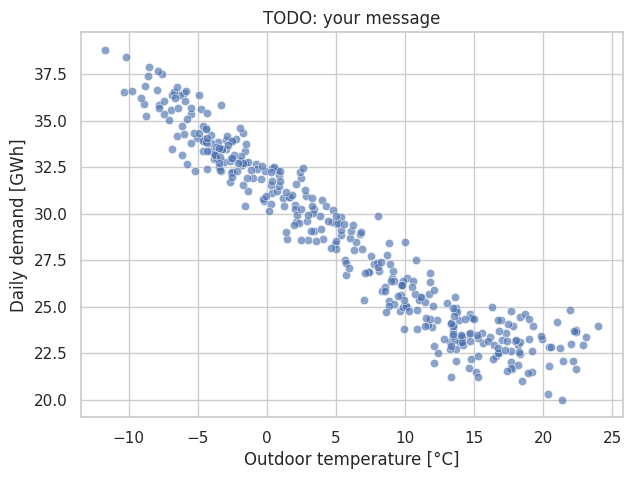

In [35]:
# OPTION A — temperature vs demand
ee = energy_daily.query("country == 'Estonia'")

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=ee,
    x="temperature_c",
    y="demand_gwh",
    alpha=0.65,
    ax=ax
)
ax.set_title("TODO: your message")
ax.set_xlabel("Outdoor temperature [°C]")
ax.set_ylabel("Daily demand [GWh]")
plt.show()

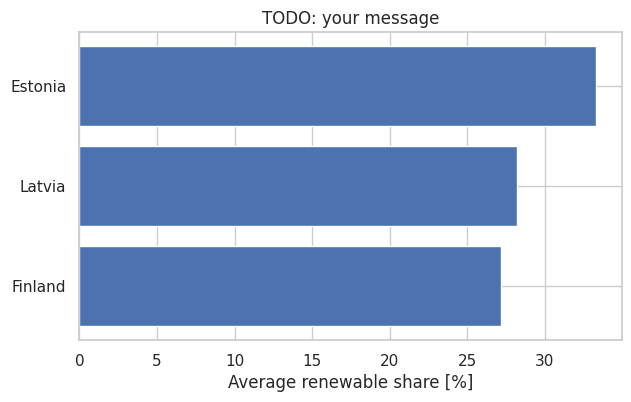

In [36]:
# OPTION B — renewable share by country
country_renew = (
    energy_daily.groupby("country", as_index=False)["renewable_share_pct"]
    .mean()
    .sort_values("renewable_share_pct")
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(country_renew["country"], country_renew["renewable_share_pct"])
ax.set_title("TODO: your message")
ax.set_xlabel("Average renewable share [%]")
plt.show()

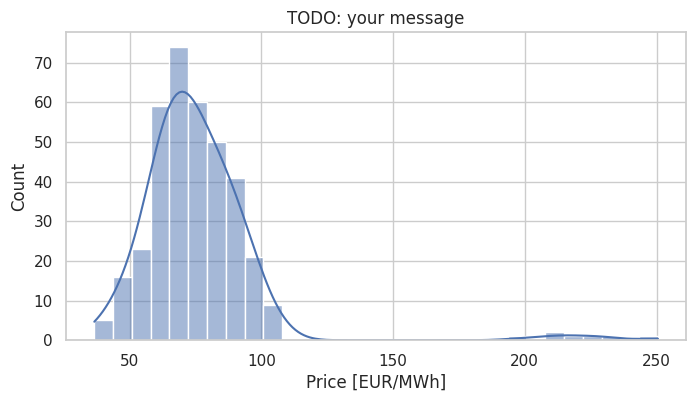

In [37]:
# OPTION C — Estonia electricity-price distribution
ee = energy_daily.query("country == 'Estonia'")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=ee,
    x="price_eur_mwh",
    bins=30,
    kde=True,
    ax=ax
)
ax.set_title("TODO: your message")
ax.set_xlabel("Price [EUR/MWh]")
plt.show()

In [38]:
final_answer = {
    "option_used": "A / B / C",
    "claim": "WRITE HERE",
    "one_way_the_plot_could_mislead": "WRITE HERE",
}
final_answer

{'option_used': 'A / B / C',
 'claim': 'WRITE HERE',
 'one_way_the_plot_could_mislead': 'WRITE HERE'}

# Takeaway

The main skill is not writing plotting syntax from memory.

It is understanding that:

- axis choices shape perception;
- aggregation hides and reveals structure;
- time scale changes the question;
- smoothing trades variability for structure;
- metrics and plots reveal different things;
- good visualisation requires **clarity, honesty, and consistency**.